# NYC TAXI DEMAND PREDICTION
This notebook contains the complete end-to-end workflow for the project.
It is designed to handle large datasets without crashing by processing files
in chunks, while incorporating all advanced feature engineering techniques.

## 1. Introduction & Setup

# NYC Taxi Demand Prediction

---

**Team:** CitySync
* **Members:** Suhas Kembavi (Lead), Ridam Goyal, Shreesha b s, Archit Kulkarni, Amrutha Tavva

---

## Project Goal

The objective of this project is to develop a machine learning model that accurately forecasts the hourly demand for yellow taxis across different zones in New York City. By analyzing historical trip data from the past four months, we aim to provide insights that can help optimize fleet management and reduce passenger wait times.

## Notebook Structure

This notebook follows a complete, memory-efficient data science workflow:

1.  **Introduction & Setup:** Loading all necessary libraries and mounting Google Drive.
2.  **Data Loading & Processing in Chunks:** Loading, cleaning, and aggregating the raw data file-by-file to prevent memory crashes.
3.  **Final Feature Engineering:** Creating time-based, lag, and rolling window features on the final combined dataset.
4.  **Exploratory Data Analysis (EDA):** Visualizing the cleaned data to identify key patterns and trends.
5.  **Model Preparation:** Creating preprocessing pipelines and performing a time-based train/test split.
6.  **Modeling & Evaluation:** Training our baseline (Linear Regression) and main (XGBoost) models and comparing their performance.
7.  **Conclusion & Feature Importance:** Summarizing the results and analyzing the key drivers of taxi demand.

In [ ]:
# Upgrade XGBoost
!pip install xgboost

In [ ]:
print("Step 1: Setting up the environment...")

# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import gc  # Garbage Collector interface to free up memory

# --- Modeling & Preprocessing Libraries ---
from sklearn.linear_model import LinearRegression # Import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb

# --- Configure Settings ---
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Set a consistent style for all plots for a professional look
sns.set_style('whitegrid')
# Make default plots larger and more readable
plt.rcParams['figure.figsize'] = (15, 7)
# Ignore non-critical warnings to keep the output clean
warnings.filterwarnings('ignore')

print("Environment setup complete.\n")

Step 1: Setting up the environment...
Mounted at /content/drive
Environment setup complete.



## 2. Data Loading & Processing in Chunks

To avoid using all available RAM, we process the data one file at a time.
For each monthly file, we perform all cleaning and aggregation steps.
The small, processed result from each month is stored and then combined at the end.
This is a memory-efficient approach suitable for large datasets.

#### Link to Dataset

https://drive.google.com/drive/folders/1roZpZ1XTGjO_4-AmnoWLa0MGf0wXRusS

In [ ]:
print("Step 2: Loading and processing data in memory-efficient chunks...")

# Update these file paths to match your Google Drive structure.
files = [
    "/content/drive/MyDrive/dataset/yellow_tripdata_2025-04.parquet",
    "/content/drive/MyDrive/dataset/yellow_tripdata_2025-05.parquet",
    "/content/drive/MyDrive/dataset/yellow_tripdata_2025-06.parquet",
    "/content/drive/MyDrive/dataset/yellow_tripdata_2025-07.parquet"
]

# Create an empty list to store the processed monthly data
all_demand_dfs = []

# Loop through each file path
for f in files:
    print(f"--> Processing file: {f}")

    # 1. Load ONE file at a time
    df_monthly = pd.read_parquet(f)

    # 2. Perform ALL cleaning on this single month's data
    df_monthly['tpep_pickup_datetime'] = pd.to_datetime(df_monthly['tpep_pickup_datetime'], errors='coerce')
    df_monthly['tpep_dropoff_datetime'] = pd.to_datetime(df_monthly['tpep_dropoff_datetime'], errors='coerce')
    df_monthly = df_monthly.dropna(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    df_monthly = df_monthly[(df_monthly['tpep_dropoff_datetime'] - df_monthly['tpep_pickup_datetime']).dt.total_seconds() >= 120]
    df_monthly = df_monthly[(df_monthly['tpep_dropoff_datetime'] - df_monthly['tpep_pickup_datetime']).dt.total_seconds() <= 12*3600]
    df_monthly = df_monthly[(df_monthly['trip_distance'] > 0) & (df_monthly['trip_distance'] <= 100)]
    df_monthly = df_monthly[df_monthly['fare_amount'] > 0]
    df_monthly = df_monthly[(df_monthly['passenger_count'] >= 1) & (df_monthly['passenger_count'] <= 6)]
    df_monthly = df_monthly[df_monthly['PULocationID'].between(1, 263)]

    # 3. Aggregate this single month's data into hourly demand
    df_monthly['pickup_hourly'] = df_monthly['tpep_pickup_datetime'].dt.floor('H')
    monthly_demand = (
        df_monthly.groupby(['pickup_hourly', 'PULocationID'])
          .size()
          .reset_index(name='demand_count')
    )

    # 4. Create aggregated trip features from the raw monthly data
    agg_features = (
        df_monthly.groupby(['pickup_hourly', 'PULocationID'])
          .agg(
              avg_trip_distance=('trip_distance', 'mean'),
              avg_fare_amount=('fare_amount', 'mean'),
              avg_passenger_count=('passenger_count', 'mean')
          )
          .reset_index()
    )

    # 5. Merge the new features with the monthly demand data
    monthly_demand = monthly_demand.merge(agg_features, on=['pickup_hourly', 'PULocationID'], how='left')

    # 6. Append the fully featured monthly result to our list
    all_demand_dfs.append(monthly_demand)

    # 7. Free up memory before starting the next loop
    del df_monthly
    del monthly_demand
    del agg_features
    gc.collect()

# Finally, combine the small, processed DataFrames from each month into one
print("\nCombining all processed chunks...")
demand = pd.concat(all_demand_dfs, ignore_index=True)

print(f"Successfully processed all files. Shape of final aggregated data: {demand.shape}\n")


Step 2: Loading and processing data in memory-efficient chunks...
--> Processing file: /content/drive/MyDrive/dataset/yellow_tripdata_2025-04.parquet
--> Processing file: /content/drive/MyDrive/dataset/yellow_tripdata_2025-05.parquet
--> Processing file: /content/drive/MyDrive/dataset/yellow_tripdata_2025-06.parquet
--> Processing file: /content/drive/MyDrive/dataset/yellow_tripdata_2025-07.parquet

Combining all processed chunks...
Successfully processed all files. Shape of final aggregated data: (308803, 6)



## 3. Final Feature Engineering

Now that we have a clean, combined dataset, we can create the final features
that rely on the complete timeline. This includes cyclical features for time
and lag/rolling features which are powerful predictors in time-series problems.

In [ ]:
print("Step 3: Engineering final features on the combined dataset...")

# --- 3.1: Create Time-Based Features ---
demand['hour'] = demand['pickup_hourly'].dt.hour
demand['weekday'] = demand['pickup_hourly'].dt.weekday
demand['is_weekend'] = demand['weekday'].isin([5, 6]).astype(int)
demand['hour_sin'] = np.sin(2 * np.pi * demand['hour'] / 24)
demand['hour_cos'] = np.cos(2 * np.pi * demand['hour'] / 24)
demand['weekday_sin'] = np.sin(2 * np.pi * demand['weekday'] / 7)
demand['weekday_cos'] = np.cos(2 * np.pi * demand['weekday'] / 7)

# --- 3.2: Create Lag and Rolling Window Features ---
# This requires sorting the data by location and time
demand = demand.sort_values(by=['PULocationID', 'pickup_hourly'])
# Lag features: demand from previous time periods
demand['demand_lag_1hr'] = demand.groupby('PULocationID')['demand_count'].shift(1)
demand['demand_lag_24hr'] = demand.groupby('PULocationID')['demand_count'].shift(24)
# Rolling window features: average demand over a recent period
demand['demand_rolling_mean_3hr'] = demand.groupby('PULocationID')['demand_count'].shift(1).rolling(window=3).mean()

# Drop rows with NaN values created by lag/rolling features
demand.dropna(inplace=True)

print("Final feature engineering complete.")
print(f"Final dataset shape after adding all features: {demand.shape}\n")



Step 3: Engineering final features on the combined dataset...
Final feature engineering complete.
Final dataset shape after adding all features: (303001, 16)



## 4. Exploratory Data Analysis (EDA)

In this section, we visualize the processed data to discover patterns,
trends, and insights. This helps us understand the problem better and
validate our feature engineering choices.

Step 4: Performing Exploratory Data Analysis...


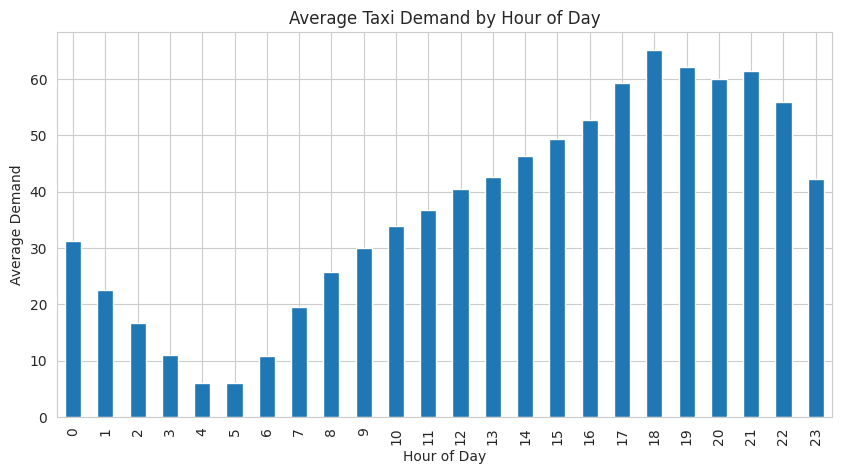

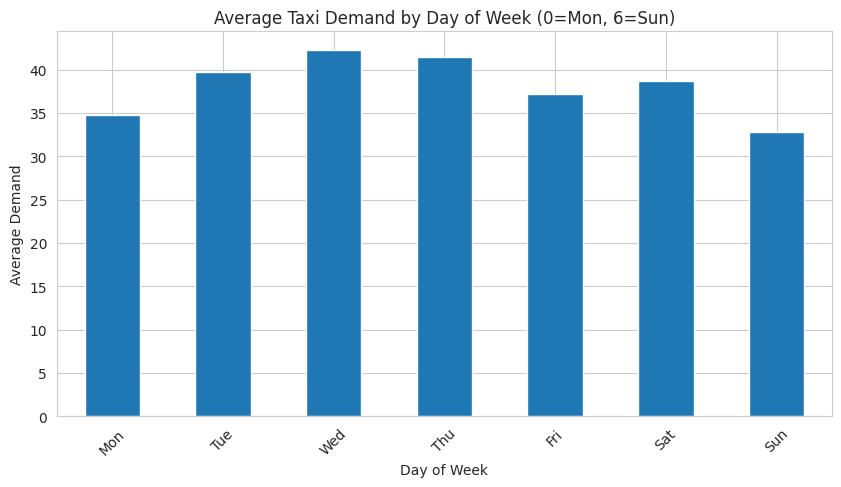

EDA complete.



In [ ]:
print("Step 4: Performing Exploratory Data Analysis...")

# --- 4.1: Demand by Hour of Day ---
plt.figure(figsize=(10, 5))
demand.groupby('hour')['demand_count'].mean().plot(kind='bar')
plt.title("Average Taxi Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.show()

# --- 4.2: Demand by Day of Week ---
plt.figure(figsize=(10, 5))
demand.groupby('weekday')['demand_count'].mean().plot(kind='bar')
plt.title("Average Taxi Demand by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
plt.show()
print("EDA complete.\n")



## 5. Model Preparation

Here, we prepare the final dataset for the machine learning models.
This involves defining our features and target, creating preprocessing
pipelines for scaling and encoding, and performing a time-based split
of the data into training and testing sets.

In [ ]:
print("Step 5: Preparing data for modeling...")

# --- 5.1: Define Features (X) and Target (y) ---
y = demand['demand_count']
feature_cols = [
    'PULocationID', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    'avg_trip_distance', 'avg_fare_amount', 'avg_passenger_count',
    'demand_lag_1hr', 'demand_lag_24hr', 'demand_rolling_mean_3hr'
]
X = demand[feature_cols]

# --- 5.2: Create Preprocessing Pipelines ---
numeric_features = ['avg_trip_distance', 'avg_fare_amount', 'avg_passenger_count', 'demand_lag_1hr', 'demand_lag_24hr', 'demand_rolling_mean_3hr']
categorical_features = ['PULocationID']
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough'
)
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough'
)

# --- 5.3: Time-Based Train/Test Split ---
demand = demand.sort_values("pickup_hourly")
cutoff_date = demand['pickup_hourly'].max() - pd.Timedelta(days=14)
train_idx = demand['pickup_hourly'] < cutoff_date
test_idx = demand['pickup_hourly'] >= cutoff_date

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

# Apply the preprocessing pipelines
X_train_lr = preprocessor_lr.fit_transform(X_train)
X_test_lr = preprocessor_lr.transform(X_test)
X_train_xgb = preprocessor_xgb.fit_transform(X_train)
X_test_xgb = preprocessor_xgb.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("Data preparation complete.\n")


Step 5: Preparing data for modeling...
Train size: 266031 | Test size: 36970
Data preparation complete.



## 6. Modeling & Evaluation

This section is where we conduct our main experiment. We follow a two-model
strategy to rigorously evaluate our approach.
#
1.  **Baseline Model (Linear Regression):** We start with a simple model to
    establish a benchmark performance. This answers the question: "How well can
    we predict demand with just basic linear relationships?" The score from this
    model is the minimum we must beat.

2.  **Main Model (XGBoost):** We then train an advanced gradient boosting model.
    It is expected to perform much better because it can learn complex, non-linear
    patterns and interactions between our features.

We evaluate both models using RMSE to see which one's predictions are closer
to the actual demand counts

In [ ]:
print("Step 6: Training and evaluating models...")

# --- 6.1: Baseline Model - Linear Regression ---
print("--- Training Linear Regression ---")
# Create an instance of the model
lr_model = LinearRegression()
# Train the model on the preprocessed training data
lr_model.fit(X_train_lr, y_train)
# Make predictions on the preprocessed test data
lr_predictions = lr_model.predict(X_test_lr)

# Calculate performance metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print(f"Linear Regression MAE: {lr_mae:.2f}")
print(f"Linear Regression RMSE: {lr_rmse:.2f}\n")


# --- 6.2: Main Model - XGBoost ---
print("--- Training XGBoost ---")
# Create an instance of the XGBoost model with selected hyperparameters
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model with early stopping to prevent overfitting
# This monitors the performance on the test set and stops if it doesn't improve
xgb_model.fit(X_train_xgb, y_train,
              eval_set=[(X_test_xgb, y_test)],
              verbose=False)

# Make predictions on the test data
xgb_predictions = xgb_model.predict(X_test_xgb)

# Calculate performance metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost RMSE: {xgb_rmse:.2f}\n")

Step 6: Training and evaluating models...
--- Training Linear Regression ---
Linear Regression MAE: 7.69
Linear Regression RMSE: 15.25

--- Training XGBoost ---
XGBoost MAE: 4.96
XGBoost RMSE: 10.90



## 7. Conclusion & Feature Importance

This is the "So what?" section. Here, we interpret the results of our
experiment and extract valuable insights. We don't just want a good score; we
want to understand what drives taxi demand.

1.  **Performance Summary:** We'll declare the "winner" of our experiment
     (XGBoost) and quantify its improvement over the baseline.

2.  **Feature Importance:** We'll ask our best model (XGBoost) what "clues"
     it found most useful. This analysis turns our model from a black box into
     an insightful tool that can provide actionable business intelligence.


Step 7: Final analysis and conclusion...

--- Model Performance Summary ---
Baseline (Linear Regression) RMSE: 15.25
Main Model (XGBoost) RMSE: 10.90
XGBoost shows a 28.55% improvement in RMSE over the baseline.


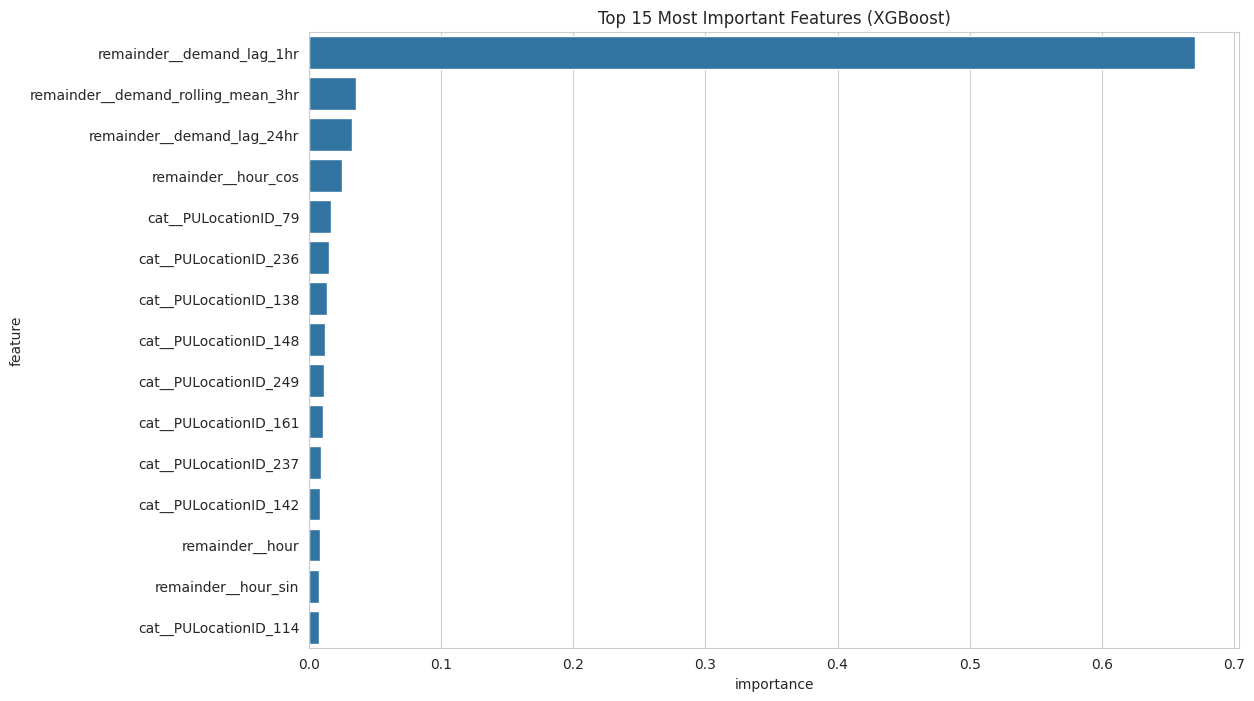


Project workflow complete.


In [ ]:
print("Step 7: Final analysis and conclusion...")

# --- 7.1: Performance Summary ---
print("\n--- Model Performance Summary ---")
print(f"Baseline (Linear Regression) RMSE: {lr_rmse:.2f}")
print(f"Main Model (XGBoost) RMSE: {xgb_rmse:.2f}")
improvement = ((lr_rmse - xgb_rmse) / lr_rmse) * 100
print(f"XGBoost shows a {improvement:.2f}% improvement in RMSE over the baseline.")

# --- 7.2: Feature Importance ---
xgb_feature_names = preprocessor_xgb.get_feature_names_out()
feature_importances = pd.DataFrame({'feature': xgb_feature_names, 'importance': xgb_model.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances.head(15), x='importance', y='feature')
plt.title("Top 15 Most Important Features (XGBoost)")
plt.show()

print("\nProject workflow complete.")